In [2]:
from noise import pnoise2
import numpy as np

In [3]:
def add_nested_arrays(a, b):
    final = []
    for row_a, row_b in zip(a, b):
        final.append([x + y for x, y in zip(row_a, row_b)])
    return final

In [4]:
def contrast_split(array, sections=2):
    min = np.min(array)
    max = np.max(array)

    for i in range(len(array)):
        for j in range(len(array)):
            array[i][j] = categorize_split(array[i][j], min, max, sections)


def categorize_split(value, min, max, sections=2):

    for i in range(sections):
        if value < (min + (i + 1) * (max - min) / sections):
            return i / sections

    return i / sections

930


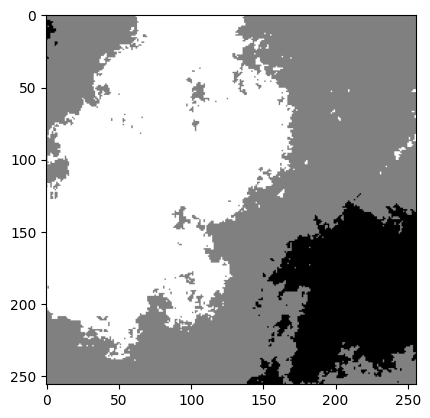

In [ ]:
import random
from typing import List
import matplotlib.pyplot as plt


def generate_seed() -> int:
    """Generate a random seed."""
    return random.randint(0, 100)


def initialize_final_pic(n: int) -> List[List[float]]:
    """Initialize the final picture array with zeros."""
    return [[0 for _ in range(n)] for _ in range(n)]


def generate_perlin_noise(
    xpix: int, ypix: int, size: int, real_seed: int, octave: int
) -> List[List[float]]:
    """
    Generate Perlin noise for given parameters.

    Args:
        xpix (int): Number of pixels in x direction.
        ypix (int): Number of pixels in y direction.
        size (int): Size of the noise.
        real_seed (int): Seed for the noise.
        octave (int): Octave of the noise.
    """
    final_pic = initialize_final_pic(xpix)
    for i in range(xpix):
        for j in range(ypix):
            noise_val = pnoise2(
                (i / xpix) * size + real_seed,
                (j / ypix) * size + real_seed,
                octave,
                0.8,
            )
            final_pic[i][j] += noise_val
    return final_pic


def apply_contrast_split(final_pic: List[List[float]], sections: int) -> None:
    """
    Apply contrast split to the final picture.

    Args:
        final_pic (List[List[float]]): Final picture array.
        sections (int): Number of sections to split the contrast.
    """
    contrast_split(final_pic, sections)


def plot_image(image: List[List[float]], cmap: str = "gray") -> None:
    """Plot the given image."""
    plt.imshow(image, cmap=cmap)
    plt.show()


def main_execution(octaves: List[int], n: int, size: int, splits: int) -> None:
    seed = generate_seed()
    real_seed = seed * 10

    final_pic = initialize_final_pic(n)

    for index, octave in enumerate(octaves):
        xpix, ypix = n, n
        noise_pic = generate_perlin_noise(xpix, ypix, size, real_seed, octave)
        final_pic = add_nested_arrays(final_pic, noise_pic)

    print(real_seed)
    apply_contrast_split(final_pic, splits)
    plot_image(final_pic)


# Main execution
octaves = [1, 100]
n = 256
size = 1
main_execution(octaves, n, size, 3)

In [9]:
from aoe2mapgenerator.units.wallgenerators.perlin import PerlinGenerator
from aoe2mapgenerator.map.map_manager import MapManager

In [10]:
n = 256
manager = MapManager(n)
pgen = PerlinGenerator(manager.get_map())

In [11]:
manager.point_manager.add_point_collection(
    "base", [(i, j) for i in range(n) for j in range(n)]
)

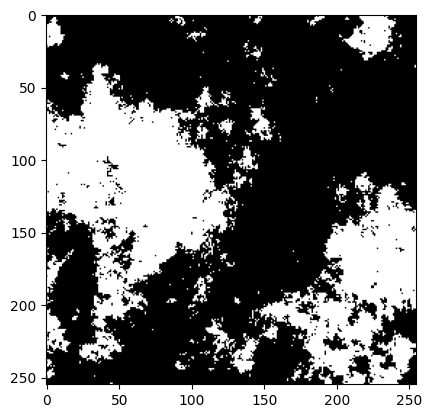

In [183]:
matrix = pgen.generate_perlin(
    point_collection=manager.point_manager.get_point_collection("base"),
    sections=2,
    octaves=[9],
    noise_size=1,
)

pgen.display(matrix)